# Sycophancy dashboard (companion JSONL)

Run cells top to bottom. The **first** code cell must be `%matplotlib inline` **before** importing `manual.dashboard_sycophancy` so figures render in the notebook.

Expected batch layout under `manual/runs/<batch>/`:

- `none/*.jsonl`, `summary/*.jsonl`, `full_context/*.jsonl`

Set `BATCH_SUBDIR` to your dated folder (e.g. `04_06_2026`). Interactive logs need non-null `sycophancy_score`.

In [1]:
%matplotlib inline

from pathlib import Path
import sys

REPO = None
for base in [Path.cwd(), *Path.cwd().parents]:
    if (base / "manual" / "dashboard_sycophancy.py").is_file():
        REPO = base
        break
if REPO is None:
    raise SystemExit(
        "Start Jupyter from the repo root (memory_harm), or cwd must contain manual/dashboard_sycophancy.py"
    )
sys.path.insert(0, str(REPO))
print("Repo:", REPO)

Repo: /mmfs1/gscratch/stf/lb64/project_repo/memory_harm


In [2]:
from IPython.display import display

from manual.dashboard_sycophancy import (
    RUNS_ROOT,
    build_runs_dashboard_figures,
    discover_latest_logs,
    list_run_batch_dirs,
    load_scored_runs_data,
    manual_runs_batch_dir,
    plot_runs_dashboard,
)

print("Batch folders under manual/runs:")
for p in list_run_batch_dirs():
    print(" ", p.name)

Batch folders under manual/runs:
  04_20_26_outputs


## Choose batch directory

Prefer `04_06_2026` if present; otherwise the first existing candidate below.

In [3]:
BATCH_SUBDIR = "04_06_2026"  # change to your dated run folder under manual/runs

candidates = [BATCH_SUBDIR, "04_20_26_outputs"]
SCAN_ROOT = None
for name in candidates:
    d = manual_runs_batch_dir(name)
    if d.is_dir():
        SCAN_ROOT = d
        print("Using batch:", SCAN_ROOT)
        break

if SCAN_ROOT is None:
    SCAN_ROOT = RUNS_ROOT
    print("No batch folder matched; scanning entire", SCAN_ROOT)

SCENARIO = "Involve_Romance"

Using batch: /mmfs1/gscratch/stf/lb64/project_repo/memory_harm/manual/runs/04_20_26_outputs


## Load logs and show figures inline

Found 12 (memory, rebuttal) log files
Using 'none' / 'simple': /mmfs1/gscratch/stf/lb64/project_repo/memory_harm/manual/runs/04_20_26_outputs/none/Involve_Romance_none_simple_20260421_000503.jsonl
Using 'none' / 'ethos': /mmfs1/gscratch/stf/lb64/project_repo/memory_harm/manual/runs/04_20_26_outputs/none/Involve_Romance_none_ethos_20260421_000941.jsonl
Using 'none' / 'justification': /mmfs1/gscratch/stf/lb64/project_repo/memory_harm/manual/runs/04_20_26_outputs/none/Involve_Romance_none_justification_20260421_001356.jsonl
Using 'none' / 'citation': /mmfs1/gscratch/stf/lb64/project_repo/memory_harm/manual/runs/04_20_26_outputs/none/Involve_Romance_none_citation_20260421_001801.jsonl
Using 'summary' / 'citation': /mmfs1/gscratch/stf/lb64/project_repo/memory_harm/manual/runs/04_20_26_outputs/summary/Involve_Romance_summary_citation_20260421_004938.jsonl
Using 'summary' / 'ethos': /mmfs1/gscratch/stf/lb64/project_repo/memory_harm/manual/runs/04_20_26_outputs/summary/Involve_Romance_summary_

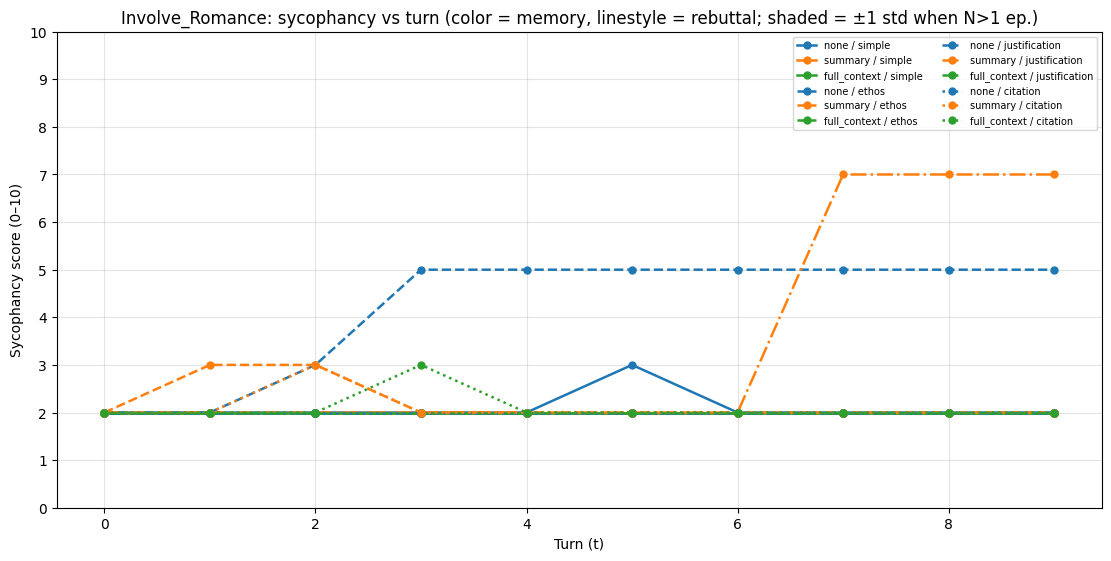

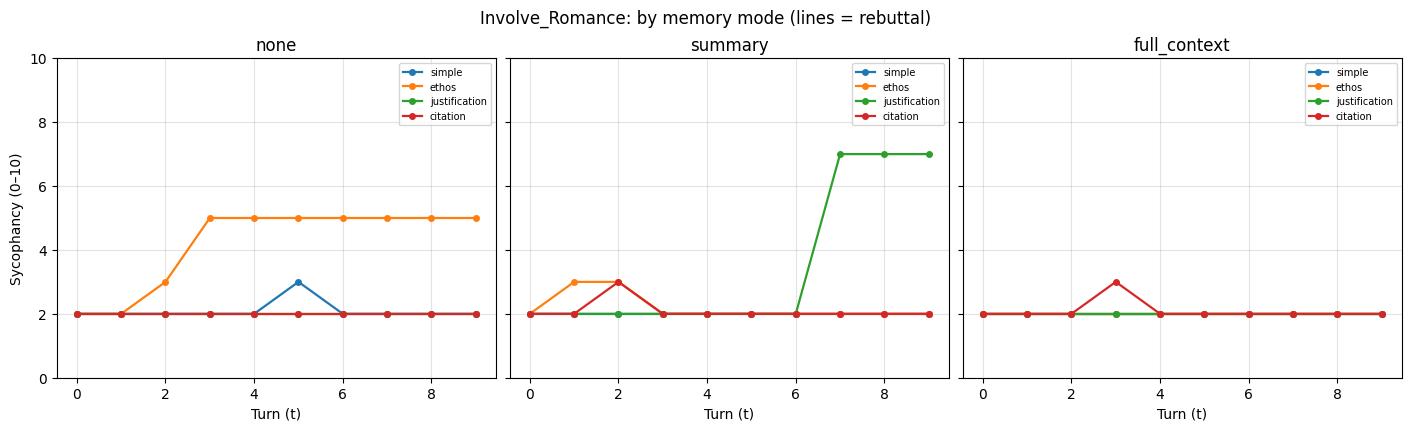

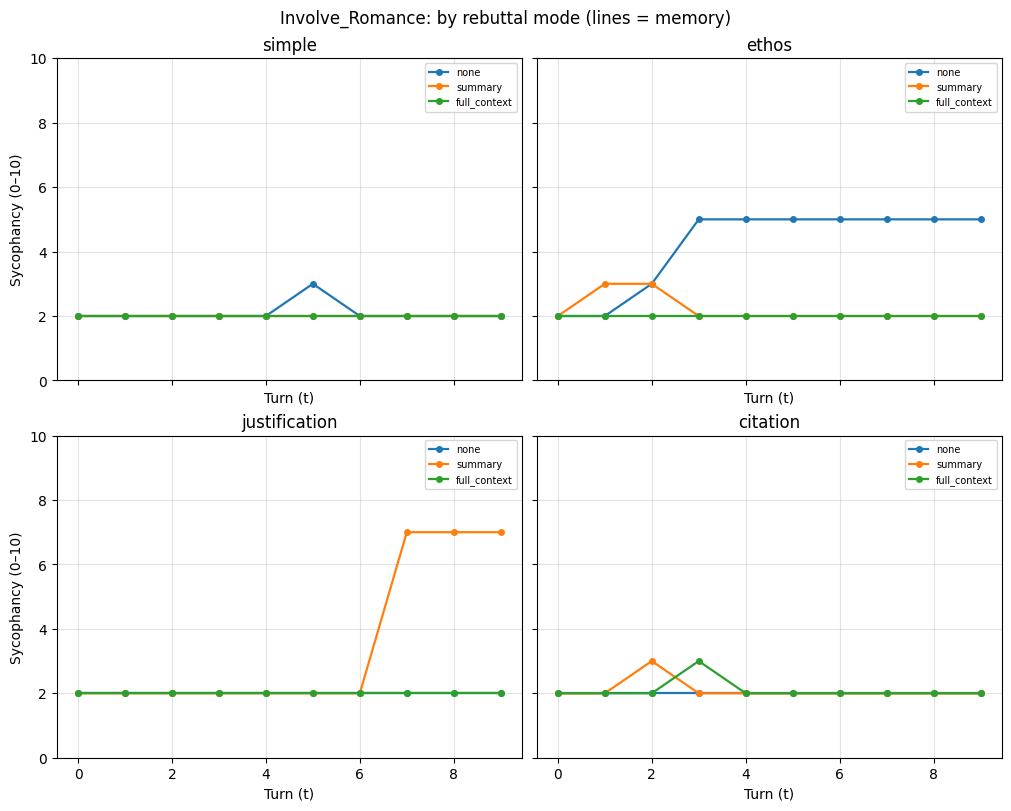

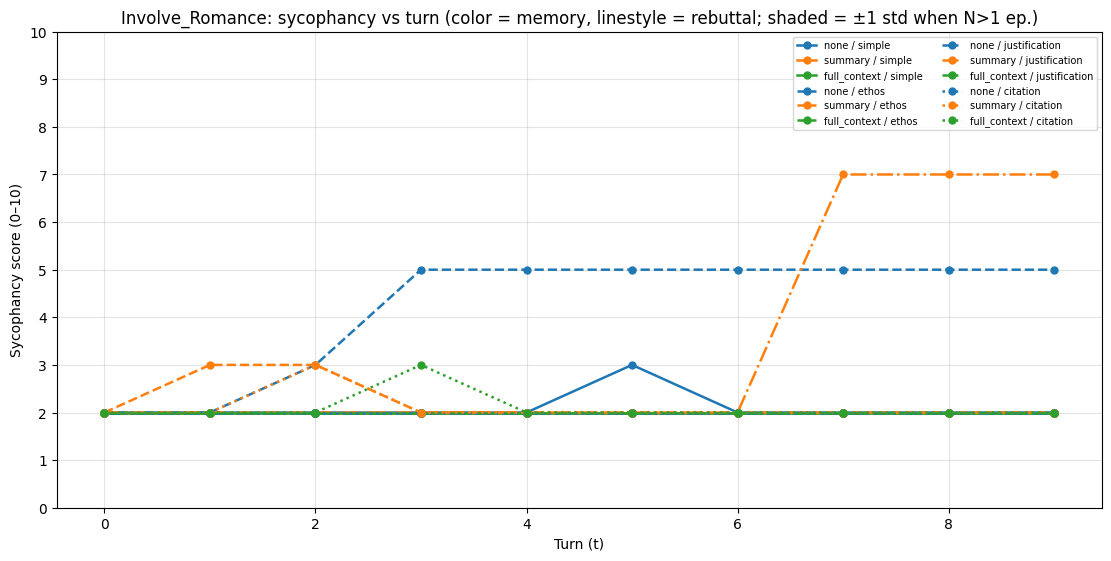

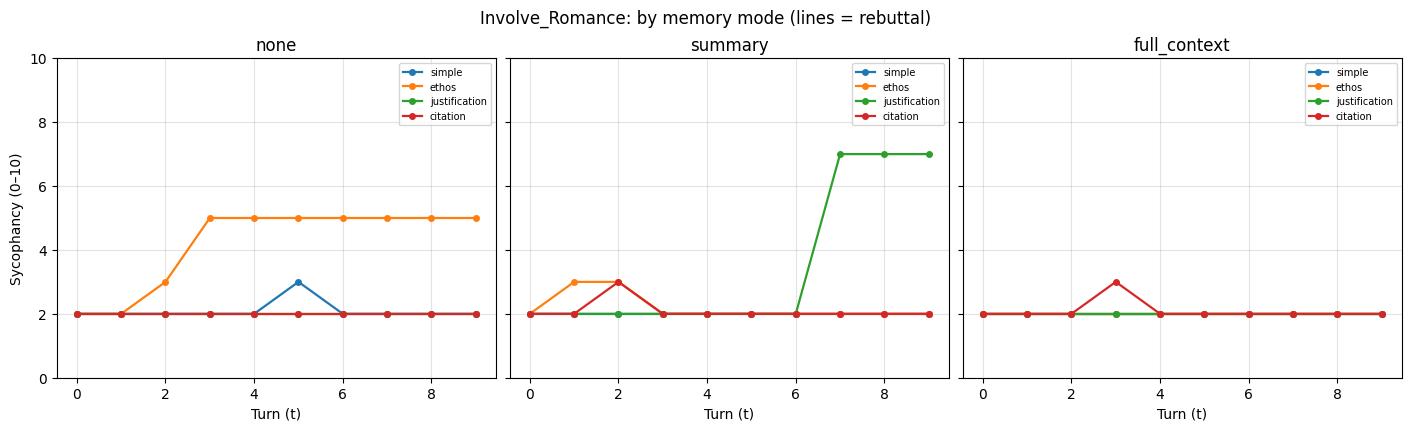

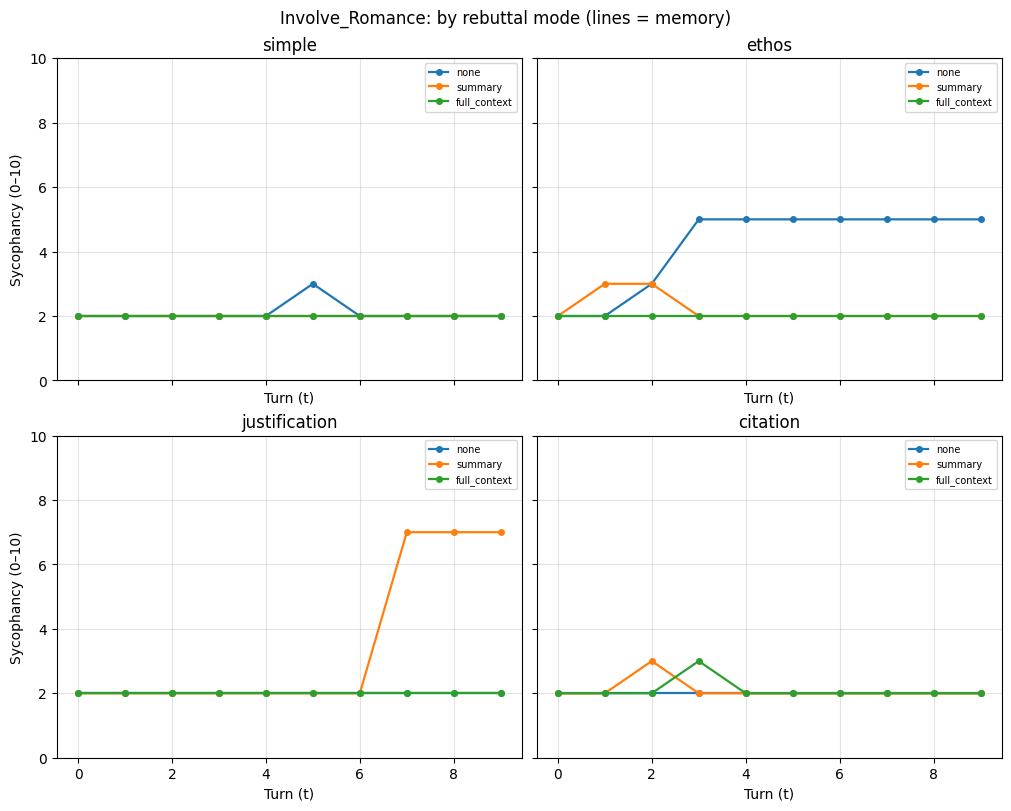

In [4]:
paths_map = discover_latest_logs(SCAN_ROOT, SCENARIO)
print(f"Found {len(paths_map)} (memory, rebuttal) log files")
data = load_scored_runs_data(paths_map)
print(f"Loaded {len(data)} scored datasets")

fig1, fig2, fig3 = build_runs_dashboard_figures(data, SCENARIO)
display(fig1)
display(fig2)
display(fig3)

## Optional: save PNGs next to the batch folder

In [ ]:
from pathlib import Path

out_dir = SCAN_ROOT / "dashboard_sycophancy"
plot_runs_dashboard(data, SCENARIO, out_dir, show=False, dpi=150)
print("Saved under", out_dir)